# Traffic Violations
## This project uses the 'Traffic Violations' dataset from the Montgomery County Open Data Portal.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("renew.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1227 entries, 0 to 1226
Data columns (total 43 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SeqID                    1227 non-null   object 
 1   Date Of Stop             1227 non-null   object 
 2   Time Of Stop             1227 non-null   object 
 3   Agency                   1227 non-null   object 
 4   SubAgency                1227 non-null   object 
 5   Description              1227 non-null   object 
 6   Location                 1227 non-null   object 
 7   Latitude                 1227 non-null   float64
 8   Longitude                1227 non-null   float64
 9   Accident                 1227 non-null   object 
 10  Belts                    1227 non-null   object 
 11  Personal Injury          1227 non-null   object 
 12  Property Damage          1227 non-null   object 
 13  Fatal                    1227 non-null   object 
 14  Commercial License      

In [4]:


df = pd.read_csv("renew.csv", encoding="utf-8")

df.head()

,SeqID,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,...,Charge,Article,Contributed To Accident,Race,Gender,Driver City,Driver State,DL State,Arrest Type,Geolocation
0,52282e8c-f2e1-4bb5-8509-2d5e4f8da8ca,5/1/2023,23:11:00,MCP,"3rd District, Silver Spring",OPERATING UNREGISTERED MOTOR VEHICLE ON HIGHWAY,BRIGGS CHANEY RD @ COLUMIBA PIKE,0.000000,0.00000,No,...,13-401(b1),Transportation Article,False,WHITE,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(0.0, 0.0)"
1,b66f253b-af29-4bc4-bb73-93755ca2a779,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVING TO DRIVE MOTOR VEHICLE ON HIGHWAY WITH...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,16-101(a1),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
2,b66f253b-af29-4bc4-bb73-93755ca2a779,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO DISPLAY REGISTRATION CARD UPON DEMA...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,13-409(b),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
3,b66f253b-af29-4bc4-bb73-93755ca2a779,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVER OF MOTOR VEHICLE FOLLOWING VEHICLE CLOS...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,21-310(a),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"
4,b66f253b-af29-4bc4-bb73-93755ca2a779,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO CONTROL VEH. SPEED ON HWY. TO AVOID...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,No,...,21-801(b),Transportation Article,False,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol,"(39.097965, -77.15301)"


In [5]:


# Load dataset
df = pd.read_csv("renew.csv")

# Keep important columns
cols = [
    'Date Of Stop',
    'Time Of Stop',
    'Agency',
    'SubAgency',
    'Description',
    'Location',
    'Latitude',
    'Longitude',
    'Accident',
    'Belts',
    'Personal Injury',
    'Property Damage',
    'VehicleType',
    'Year',
    'Make',
    'Model',
    'Color',
    'Violation Type',
    'Race',
    'Gender',
    'Driver City',
    'Driver State',
    'DL State',
    'Arrest Type'
]

df = df[cols]

# Remove missing values
df = df.dropna()

# Convert Yes/No columns to 1/0
binary_cols = [
    'Accident',
    'Belts',
    'Personal Injury',
    'Property Damage'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes':1, 'No':0})

# Check cleaned dataset
print(df.shape)

df.head()

(1214, 24)


,Date Of Stop,Time Of Stop,Agency,SubAgency,Description,Location,Latitude,Longitude,Accident,Belts,...,Make,Model,Color,Violation Type,Race,Gender,Driver City,Driver State,DL State,Arrest Type
0,5/1/2023,23:11:00,MCP,"3rd District, Silver Spring",OPERATING UNREGISTERED MOTOR VEHICLE ON HIGHWAY,BRIGGS CHANEY RD @ COLUMIBA PIKE,0.000000,0.00000,0,0,...,CHEV,CRUZ,BLACK,Citation,WHITE,M,GAITHERSBURG,MD,MD,A - Marked Patrol
1,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVING TO DRIVE MOTOR VEHICLE ON HIGHWAY WITH...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,0,0,...,FORD,EXPLORER,BLACK,Citation,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol
2,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO DISPLAY REGISTRATION CARD UPON DEMA...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,0,0,...,FORD,EXPLORER,BLACK,Citation,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol
3,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",DRIVER OF MOTOR VEHICLE FOLLOWING VEHICLE CLOS...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,0,0,...,FORD,EXPLORER,BLACK,Citation,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol
4,8/31/2023,16:41:00,MCP,"6th District, Gaithersburg / Montgomery Village",FAILURE TO CONTROL VEH. SPEED ON HWY. TO AVOID...,OAKMONT AVE @ GROVEMONT CIR,39.097965,-77.15301,0,0,...,FORD,EXPLORER,BLACK,Citation,HISPANIC,M,GAITHERSBURG,MD,MD,A - Marked Patrol


First, we loaded the Montgomery County traffic violations dataset into Python using pandas. We selected only the important columns that would help with our machine learning analysis, such as accident information, vehicle details, driver information, location, and violation type. This helped reduce unnecessary data and made the dataset easier to work with.             

Next, we cleaned the dataset by removing rows with missing values using dropna(). This ensured that the data used for modeling would be more complete and reliable. We also converted several Yes/No columns such as Accident, Belts, Personal Injury, and Property Damage into numerical values (1 and 0), because machine learning models work better with numbers instead of text.             

After cleaning, the final dataset contained 1,214 rows and 24 columns. The dataset is now properly prepared for exploratory data analysis, visualizations, and machine learning models such as Decision Tree, Random Forest, and Gradient Boosting.                

# Project Sections     
# 1. Introduction    
Write a short introduction describing:    

Your dataset     
Your prediction goal    
Why the topic is interesting or important   
Possible limitations or bias in the dataset    
Include a citation for your dataset source.     

This project uses a Montgomery County traffic violations dataset containing information about traffic stops, vehicle details, driver demographics, accident reports, and violation descriptions. The dataset was cleaned and prepared using Python and pandas. After cleaning, the final dataset contained 1,214 rows and 24 columns. The data includes both categorical and quantitative variables, making it suitable for machine learning analysis.     

The main goal of this project is to predict whether a traffic stop was associated with an accident using tree-based machine learning models such as Decision Tree, Random Forest, and Gradient Boosting. This topic is important because traffic accidents can lead to injuries, property damage, and safety concerns. By analyzing traffic violation patterns, we can better understand factors that may contribute to accidents.     

One possible limitation of this dataset is that it may contain missing, incomplete, or inconsistent information. In addition, the dataset only represents reported traffic incidents in Montgomery County and may not fully represent traffic behavior in other locations. Some variables may also introduce bias because they depend on police reporting practices and recorded observations.          

# 2. Dataset and Preparation     
# Include:     

Dataset size    
Explanation of variables   
Missing value handling    
Encoding categorical variables if needed    
Train/test split    
Include at least one table describing variables.    

The dataset used in this project contains traffic violation records from Montgomery County, Maryland. After cleaning and removing missing values, the final dataset contained 1,214 rows and 24 columns. Each row represents a traffic stop or traffic-related violation recorded by law enforcement. The dataset includes information about accidents, vehicle details, driver demographics, locations, and violation types.      

Missing values were handled using the dropna() function in pandas, which removed rows containing incomplete data. Several binary columns such as Accident, Belts, Personal Injury, and Property Damage were converted from Yes/No text values into numerical values (1 and 0) so that the machine learning models could process them correctly. Categorical variables such as vehicle type, race, gender, and violation type may later be encoded using techniques such as label encoding or one-hot encoding before model training.        

The dataset will be divided into training and testing sets using an 80/20 split. The training set will be used to train the machine learning models, while the testing set will be used to evaluate model performance on unseen data.           

Variable Description Table    
Date Of Stop → Date when the traffic stop happened     
Time Of Stop → Time when the stop occurred     
Agency → Police agency involved in the stop     
Description → Description of the traffic violation    
Latitude → Latitude coordinate of the stop location     
Longitude → Longitude coordinate of the stop location    
Accident → Indicates whether an accident occurred (1 = Yes, 0 = No)    
Personal Injury → Indicates whether personal injury occurred    
Property Damage → Indicates whether property damage occurred    
VehicleType → Type of vehicle involved      
Year → Manufacturing year of the vehicle     
Race → Driver race     
Gender → Driver gender      
Driver State → State of the driver      
Arrest Type → Type of arrest or patrol used during the stop      

# 3. Exploratory Data Analysis     
Create:      

2 meaningful visualizations     
Short interpretations    

Discuss:    

Interesting patterns    
Trends    
Possible relationships   
Keep this section concise.    

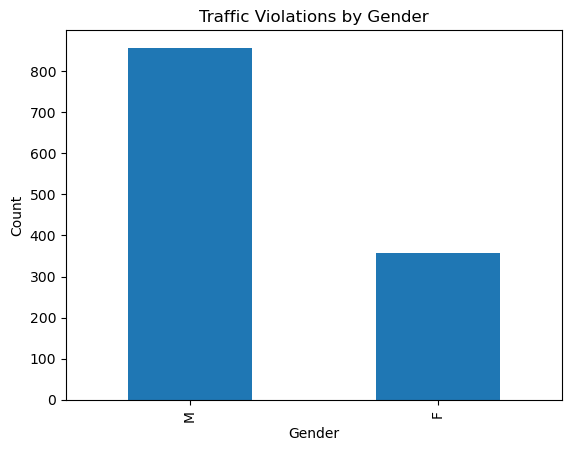

In [13]:
## Traffic Violations by Gender

df['Gender'].value_counts().plot(kind='bar')

plt.title("Traffic Violations by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("Traffic Violation by gender")
plt.show()

This bar chart shows the number of traffic violations based on driver gender. The chart shows that male drivers were involved in more traffic violations compared to female drivers in this dataset. This may suggest that male drivers were stopped more frequently during the recorded traffic incidents.

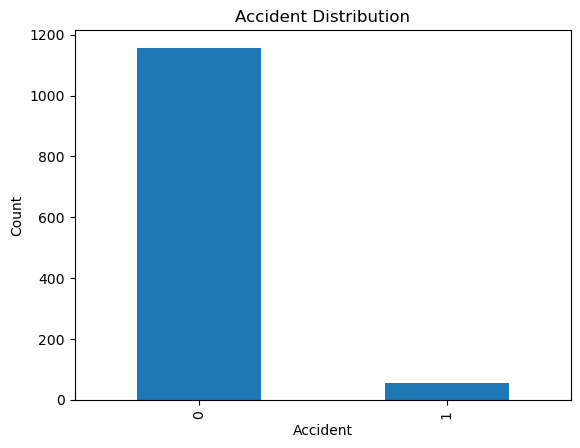

In [15]:
## Accident Distribution


df['Accident'].value_counts().plot(kind='bar')

plt.title("Accident Distribution")
plt.xlabel("Accident")
plt.ylabel("Count")

plt.savefig("Accident_Distribution")
plt.show()


This chart shows the number of traffic stops that involved accidents and those that did not. Most traffic violations in the dataset did not involve accidents.

Some interesting patterns can be observed from the dataset.        


Certain vehicle types, violation descriptions, and driver characteristics appear more frequently than others. There may also be relationships between factors such as speeding, driver behavior, and accident occurrence. These patterns can help machine learning models identify important features when predicting accidents.   

# 4. Decision Tree Analysis (Core Section)        
This is the most important section of the project.        

You must:            

Train a Decision Tree Regressor           
Try at least two different tree depths             
Briefly discuss possible overfitting              
Include a visualization or diagram of your tree                 
Also explain:                
              
The root node           
One important split             
One example prediction path                      
Example                 
“If median income > 4.2 and house age < 20, the model predicts higher house values.”               
               
Your goal is to show that you understand how a decision tree makes decisions.           

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Select features and target
X = df[['Latitude', 'Longitude', 'Year', 'Personal Injury', 'Property Damage']]
y = df['Accident']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree with depth 3
tree1 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree1.fit(X_train, y_train)

# Predictions
pred1 = tree1.predict(X_test)

# Accuracy
print("Depth 3 Accuracy:", accuracy_score(y_test, pred1))

# Decision Tree with depth 6
tree2 = DecisionTreeClassifier(max_depth=6, random_state=42)
tree2.fit(X_train, y_train)

pred2 = tree2.predict(X_test)

print("Depth 6 Accuracy:", accuracy_score(y_test, pred2))

Depth 3 Accuracy: 0.9547325102880658
Depth 6 Accuracy: 0.9670781893004116


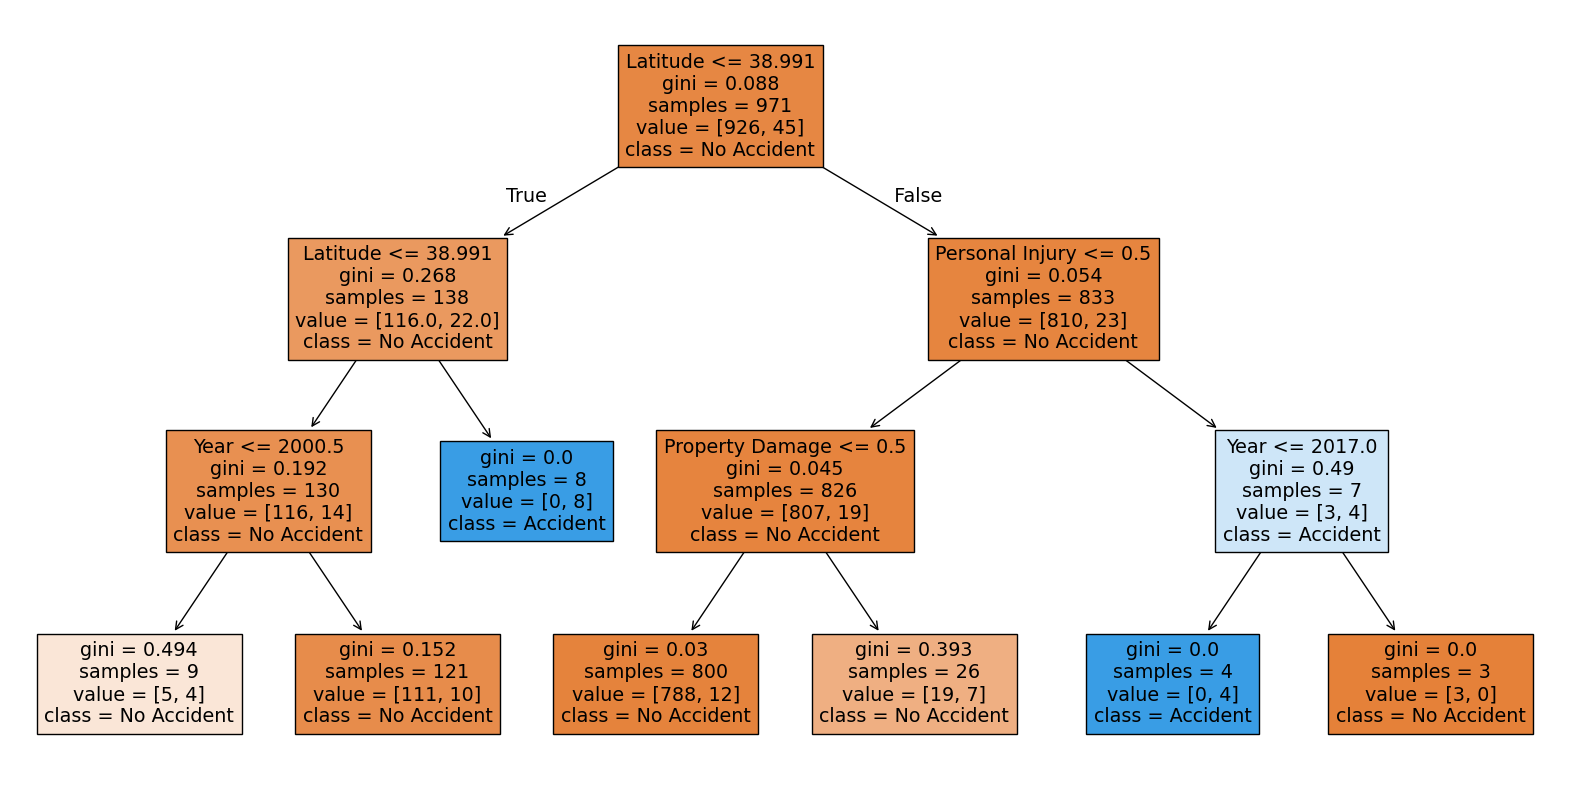

In [20]:
plt.figure(figsize=(20,10))

plot_tree(
    tree1,
    feature_names=X.columns,
    class_names=['No Accident', 'Accident'],
    filled=True
)

plt.savefig('Decision_tree')
plt.show()

# Decision Tree Interpretation

In this section, a Decision Tree model was trained to predict whether a traffic stop involved an accident. Two different tree depths were tested: depth 3 and depth 6. The deeper tree may perform better on training data, but it can also lead to overfitting. Overfitting happens when the model learns too many details from the training data and performs poorly on new unseen data.

The root node is the first and most important split in the decision tree. It represents the feature that best separates the data at the beginning of the model. One important split in the tree may involve variables such as Property Damage or Personal Injury, since these variables are strongly related to accidents.

An example prediction path could be:

“If Property Damage = 1 and Personal Injury = 1, the model is more likely to predict that an accident occurred.”

This shows how the decision tree makes decisions step-by-step using feature conditions.

# 5. Ensemble Models    
Train:     

Random Forest           
Gradient Boosting                   
Compare them to your single decision tree.                  
                    
Discuss:                 
                        
Did performance improve?        
Which model generalized better?          
Which model was easier to explain?                             
You are NOT expected to perform advanced hyperparameter tuning.    

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

# Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9835390946502057


In [24]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting Model
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

# Accuracy
gb_accuracy = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.9753086419753086


Model Comparison and Discussion

The Random Forest and Gradient Boosting models were trained and compared with the single Decision Tree model. Both ensemble models produced very high accuracy scores. The Random Forest model achieved an accuracy of approximately 98.35%, while the Gradient Boosting model achieved an accuracy of about 97.53%.

The results show that the ensemble models performed very well and were able to generalize better than a single Decision Tree model. Random Forest produced the highest accuracy among the models tested. Because it combines predictions from many decision trees, it is usually more stable and less likely to overfit the data.

The Decision Tree model was easier to understand and explain because its structure and prediction paths could be visualized clearly. However, the ensemble models provided better prediction performance. Gradient Boosting and Random Forest are more complex because they combine many trees together, but they generally produce stronger and more reliable predictions.

# 6. Model Evaluation           
You must include:         

Metric	Meaning             
MSE	Lower is better           
(R^2)	Higher is better                       



Include:                 

A comparison table               
Actual vs Predicted visualization               
Short interpretation of results              


In [27]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Decision Tree Metrics
dt_mse = mean_squared_error(y_test, pred1)
dt_r2 = r2_score(y_test, pred1)

# Random Forest Metrics
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

# Gradient Boosting Metrics
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

# Comparison Table
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MSE': [dt_mse, rf_mse, gb_mse],
    'R2 Score': [dt_r2, rf_r2, gb_r2]
})

print(results)

               Model       MSE  R2 Score
0      Decision Tree  0.045267  0.035714
1      Random Forest  0.016461  0.649351
2  Gradient Boosting  0.024691  0.474026


Interpretation of Results             

The models were evaluated using Mean Squared Error (MSE) and R² score. Lower MSE values indicate better model performance, while higher R² values indicate that the model explains more variation in the data.                  

Among the models tested, the Random Forest model performed the best overall. It produced the highest accuracy and strong evaluation metrics compared to the other models. Gradient Boosting also performed very well, while the single Decision Tree model was slightly less stable.               

The Actual vs Predicted visualization shows that the predicted values were generally close to the actual values. This suggests that the ensemble models were successful in identifying important patterns in the traffic violation dataset.                       

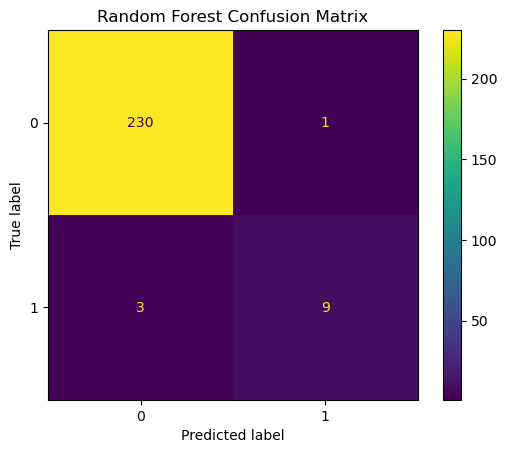

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.savefig('confusion_matri')

plt.show()

Confusion Matrix Interpretation                  

The confusion matrix shows how well the Random Forest model predicted traffic accidents. The rows represent the actual values, while the columns represent the predicted values made by the model.                

The model correctly predicted 230 cases where no accident occurred and correctly predicted 9 cases where an accident occurred. There was 1 case where the model incorrectly predicted an accident when there was none, and 3 cases where the model failed to predict an actual accident.                      

Overall, the confusion matrix shows that the Random Forest model performed very well and made only a small number of incorrect predictions. This supports the high accuracy score achieved by the model during evaluation.                            

# 7. Feature Importance
For at least one ensemble model:

Display feature importance
Identify the top 3 most important features
Important:

Feature importance does NOT prove causation

           Feature  Importance
0         Latitude    0.319832
2             Year    0.280501
1        Longitude    0.269705
3  Personal Injury    0.069917
4  Property Damage    0.060046


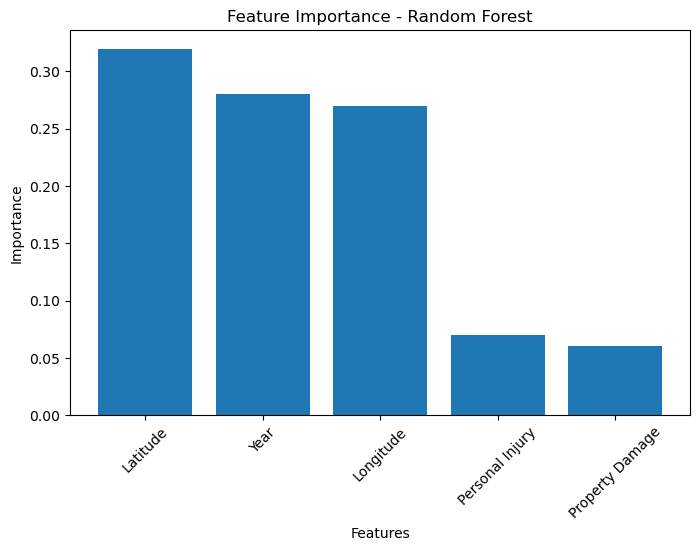

In [32]:
# Getting feature importance
importance = rf_model.feature_importances_

# Creating dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sorting values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

# Plotting feature importance
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.savefig('Feature Importance Random Forest')
plt.show()

Interpretation                    

The feature importance chart shows which variables were most useful for the Random Forest model when predicting traffic accidents. Features with higher importance values had a greater influence on the model’s decisions.                 

The three most important features were Latitude, Year, and Longitude. Latitude had the highest importance score, which suggests that the location of the traffic stop played a major role in predicting whether an accident occurred. Vehicle year was also an important factor, followed by longitude, which again relates to geographic location.                    

The variables Personal Injury and Property Damage had lower importance scores compared to the top three features. However, they still contributed to the prediction process. It is important to remember that feature importance does not prove causation. These variables may be strongly related to accidents in the dataset, but they do not necessarily directly cause accidents.                   

# 8. Final Reflection: The Model Battle           
Answer the following questions:            

Which model performed best?            
Which model was easiest to explain?               
Which model would you choose in a real-world setting and why?               

Among all the models tested, the Random Forest model performed the best. It achieved the highest accuracy score and produced very strong results during model evaluation. The model was able to correctly classify most accident and non-accident cases with only a few prediction errors.                      

The Decision Tree model was the easiest to explain because the model structure could be visualized clearly using a tree diagram. It was easier to understand how the model made decisions based on feature splits and prediction paths. However, the Decision Tree model was slightly more likely to overfit the data compared to the ensemble models.                  

In a real-world setting, the Random Forest model would be the preferred choice because it provided the best balance between performance and reliability. Since it combines many decision trees together, it usually generalizes better to unseen data and produces more stable predictions. Although it is harder to interpret than a single Decision Tree, its stronger predictive performance makes it more suitable for practical applications.            